In [1]:
from odyssey.lightning.models.cpc import CPCModel, NethackCPCBatch
from odyssey.data.cpc_dataset import mixed_dtype_to_dict, CPCDataset

import h5py
import os
import hydra
from omegaconf import OmegaConf
import torch
import torch.nn.functional as F

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logdir = "/workspace/logs/train_cpc/runs/2025-06-08_16-31-09"
chkpt_name = "last-v3.ckpt"
data_path = "/workspace/data/nld_nao_test.h5"
device = "cuda" if torch.cuda.is_available() else "cpu"

config_path = os.path.join(logdir, ".hydra", "config.yaml")
config = OmegaConf.load(config_path)
chkpt = torch.load(os.path.join(logdir, "checkpoints", chkpt_name))
data = h5py.File("./data/nld_nao_train.h5", "r")

In [3]:
print(chkpt["datamodule_hyper_parameters"]["samples_per_trajectory"])
print(chkpt["datamodule_hyper_parameters"]["bottom_bar_censor_ratio"])

48
0.5


In [4]:
lightning_model: CPCModel = hydra.utils.instantiate(config.model)
lightning_model.load_state_dict(chkpt["state_dict"])
lightning_model = lightning_model.eval()
lightning_model = lightning_model.to(device)

tty_embedding = lightning_model.tty_embedding
context_embedding = lightning_model.context_embedding
future_obs_predictor = lightning_model.future_obs_predictor
future_length = config.future_length
context_length = config.context_length

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [5]:
def dict_to_tensor(d):
    return {k: torch.tensor(v).to(device) for k, v in d.items()}

key = next(iter(data.keys()))
context = mixed_dtype_to_dict(data[key][0:context_length])
future_obs = mixed_dtype_to_dict(data[key][context_length:context_length + future_length])

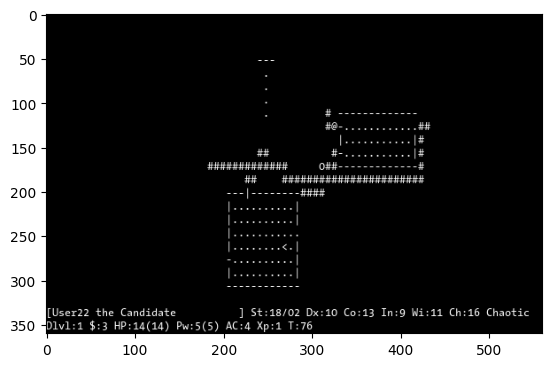

In [6]:
from odyssey.nethack.render import render_tty_chars
import matplotlib.pyplot as plt

# from odyssey.nethack.tty_utils import censor_bottom_bar

# context = mixed_dtype_to_dict(data[key][0:context_length])
# future_obs = mixed_dtype_to_dict(data[key][context_length:context_length + future_length])

# censor_bottom_bar(
#     tty_chars=context["tty_chars"],
#     tty_colors=context["tty_colors"],
#     inplace=True,
#     censor_ratio=0.5
# )

plt.imshow(render_tty_chars(context["tty_chars"][-1]))

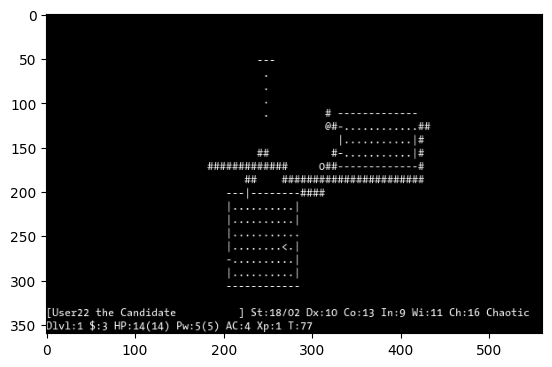

In [7]:
from odyssey.nethack.render import render_tty_chars
import matplotlib.pyplot as plt

plt.imshow(render_tty_chars(future_obs["tty_chars"][0]))

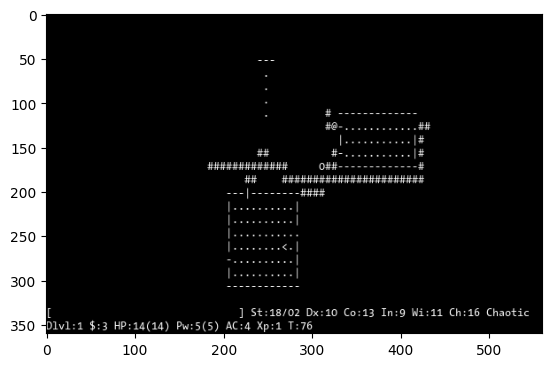

In [8]:
import numpy as np
def censor_lower_bar(tty_chars):
    tty_chars = np.copy(tty_chars)
    tty_chars[..., -2:, :] = ord(" ")
    return tty_chars

def censor_name(tty_chars):
    tty_chars = np.copy(tty_chars)
    tty_chars[..., -2, 1:31] = ord(" ")
    return tty_chars

plt.imshow(render_tty_chars(censor_name(context["tty_chars"][-1])))

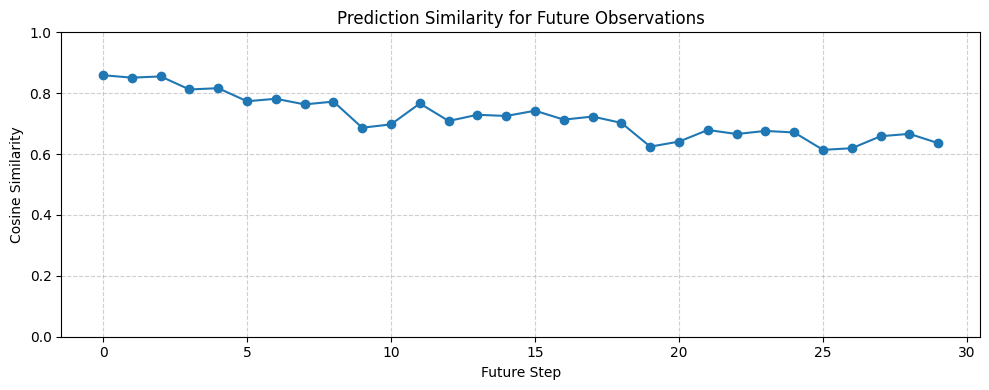

In [9]:
def encode_obs(obs):
    obs = dict_to_tensor(obs)
    return tty_embedding.encode(**obs)

def predict_future_obs(context, indices):
    context_encoding = context_embedding(context)
    obs_predictions = future_obs_predictor.forward(
        context_encoding,
        indices,
    )
    return obs_predictions

def compute_similarities(context, future_obs, indices):
    obs_predictions = predict_future_obs(context, indices)
    return F.cosine_similarity(
        future_obs,
        obs_predictions,
    )

with torch.no_grad():
    context_encoding = encode_obs(context).unsqueeze(0)
    context_encoding = context_encoding.expand(future_length, *context_encoding.shape[1:])
    future_obs_encoding = encode_obs(future_obs)
    indices = torch.arange(future_length).to(device)
    
    similarities = compute_similarities(context_encoding, future_obs_encoding, indices)

plt.figure(figsize=(10, 4))
plt.plot(similarities.cpu().numpy(), marker='o', linestyle='-', color='tab:blue')
plt.title("Prediction Similarity for Future Observations")
plt.xlabel("Future Step")
plt.ylabel("Cosine Similarity")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

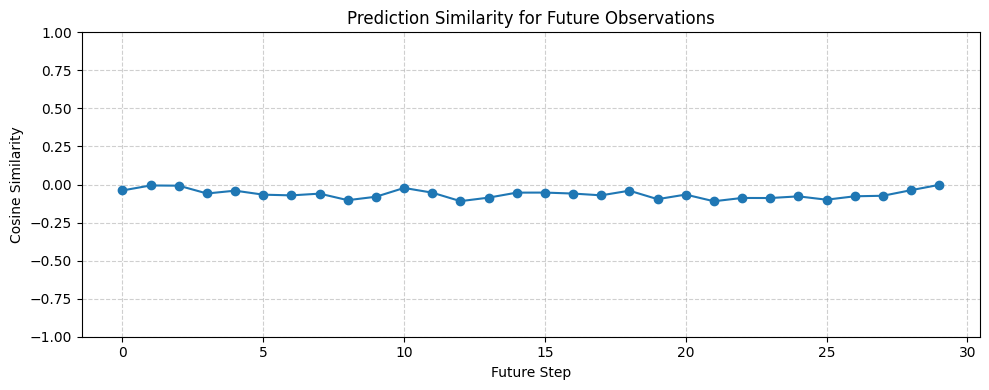

In [10]:
key = list(data.keys())[2]
wrong_future_obs = mixed_dtype_to_dict(data[key][context_length:context_length + future_length])

with torch.no_grad():
    similarities = compute_similarities(
        context_encoding,
        encode_obs(wrong_future_obs),
        indices
    )

plt.figure(figsize=(10, 4))
plt.plot(similarities.cpu().numpy(), marker='o', linestyle='-', color='tab:blue')
plt.title("Prediction Similarity for Future Observations")
plt.xlabel("Future Step")
plt.ylabel("Cosine Similarity")
plt.ylim(-1, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

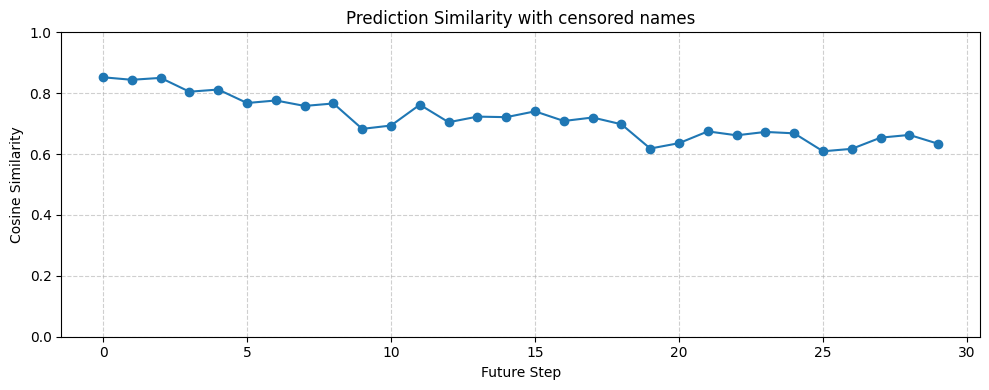

In [11]:
key = list(data.keys())[2]

censored_context = {k: np.copy(x) for k, x in context.items()}
censored_context["tty_chars"] = censor_name(censored_context["tty_chars"])

censored_future_obs = {k: np.copy(x) for k, x in future_obs.items()}
censored_future_obs["tty_chars"] = censor_name(censored_future_obs["tty_chars"])

with torch.no_grad():
    censored_context_encoding = encode_obs(censored_context).unsqueeze(0)
    censored_context_encoding = censored_context_encoding.expand(future_length, *censored_context_encoding.shape[1:])
    censored_future_obs_encoding = encode_obs(censored_future_obs)

    similarities = compute_similarities(
        censored_context_encoding,
        censored_future_obs_encoding,
        indices
    )

plt.figure(figsize=(10, 4))
plt.plot(similarities.cpu().numpy(), marker='o', linestyle='-', color='tab:blue')
plt.title("Prediction Similarity with censored names")
plt.xlabel("Future Step")
plt.ylabel("Cosine Similarity")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

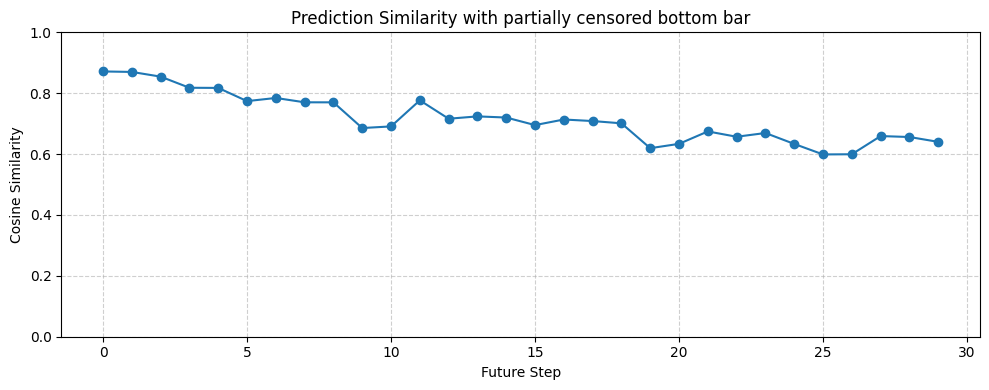

In [12]:
from odyssey.nethack.tty_utils import censor_bottom_bar

key = list(data.keys())[2]

censored_context = {k: np.copy(x) for k, x in context.items()}
censor_bottom_bar(censored_context["tty_chars"], censored_context["tty_colors"], inplace=True, censor_ratio=0.5)

censored_future_obs = {k: np.copy(x) for k, x in future_obs.items()}
censor_bottom_bar(censored_future_obs["tty_chars"], censored_future_obs["tty_colors"], inplace=True, censor_ratio=0.5)

with torch.no_grad():
    censored_context_encoding = encode_obs(censored_context).unsqueeze(0)
    censored_context_encoding = censored_context_encoding.expand(future_length, *censored_context_encoding.shape[1:])
    censored_future_obs_encoding = encode_obs(censored_future_obs)

    similarities = compute_similarities(
        censored_context_encoding,
        censored_future_obs_encoding,
        indices
    )

plt.figure(figsize=(10, 4))
plt.plot(similarities.cpu().numpy(), marker='o', linestyle='-', color='tab:blue')
plt.title("Prediction Similarity with partially censored bottom bar")
plt.xlabel("Future Step")
plt.ylabel("Cosine Similarity")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

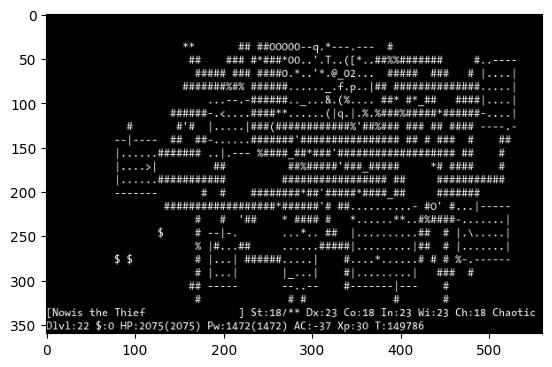

In [13]:
key = list(data.keys())[8]
start = 50
end = start + context_length
with torch.no_grad():
    raw_input_context = mixed_dtype_to_dict(data[key][start:end])
    raw_input_future_obs = mixed_dtype_to_dict(data[key][end+1])

plt.imshow(render_tty_chars(raw_input_future_obs["tty_chars"]))

In [14]:
from odyssey.nethack.constants import TTY_WIDTH, TTY_HEIGHT
from captum.attr import IntegratedGradients

def embed_tty_chars(data_dict):
    # We only encode the characters, but do not compute the final observation embedding
    # Allowing us to compute attributions for each characters embedding vector
    data_dict = dict_to_tensor(data_dict)
    data_dict = {k: v.unsqueeze(0) for k, v in data_dict.items()}
    data_dict = tty_embedding.embed_tty_chars(**data_dict)
    return data_dict

with torch.no_grad():
    raw_input_context = mixed_dtype_to_dict(data[key][start:end])
    raw_input_future_obs = mixed_dtype_to_dict(data[key][end+1])
    input_context = embed_tty_chars(raw_input_context)
    input_future_obs = embed_tty_chars(raw_input_future_obs)
input_context.requires_grad = True
input_future_obs.requires_grad = True

def create_baseline_obs():
    return {
        "tty_chars": np.full((TTY_HEIGHT, TTY_WIDTH), ord(' '), dtype=int),
        "tty_colors": np.zeros((TTY_HEIGHT, TTY_WIDTH), dtype=int),
        # We place the cursor outside the screen
        "tty_cursor": np.array([TTY_HEIGHT + 1, TTY_WIDTH + 1], dtype=int)
    }

def create_encoded_baseline_like(context, future_obs):
    baseline_obs = create_baseline_obs()
    baseline_obs = embed_tty_chars(baseline_obs)

    return baseline_obs.expand_as(context), baseline_obs.expand_as(future_obs)

with torch.no_grad():
    baseline_context, baseline_future_obs = create_encoded_baseline_like(input_context, input_future_obs)

def cpc_fn(context, future_obs, future_obs_index=0):
    context_encoding = tty_embedding.encode_embeddings(context)
    future_obs = tty_embedding.encode_embeddings(future_obs)

    context_encoding = context_embedding(context_encoding)
    obs_predictions = future_obs_predictor.forward(
        context_encoding,
        torch.full((context_encoding.shape[0],), future_obs_index, device=context_encoding.device, dtype=torch.int)
    )
    return F.cosine_similarity(future_obs, obs_predictions)

ig = IntegratedGradients(forward_func=cpc_fn)
context_attributions, future_obs_attributions = ig.attribute(
    inputs=(input_context, input_future_obs),
    baselines=(baseline_context, baseline_future_obs),
    additional_forward_args=(0,)
)

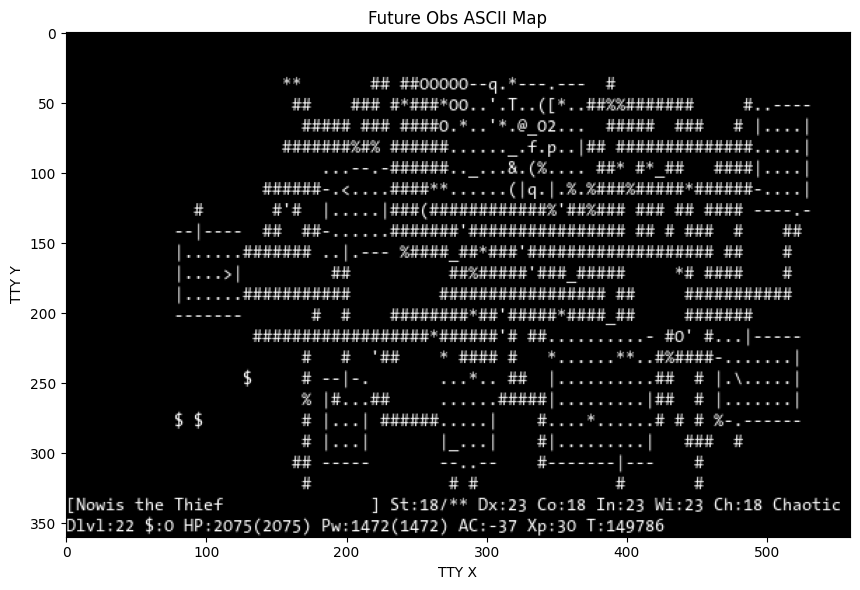

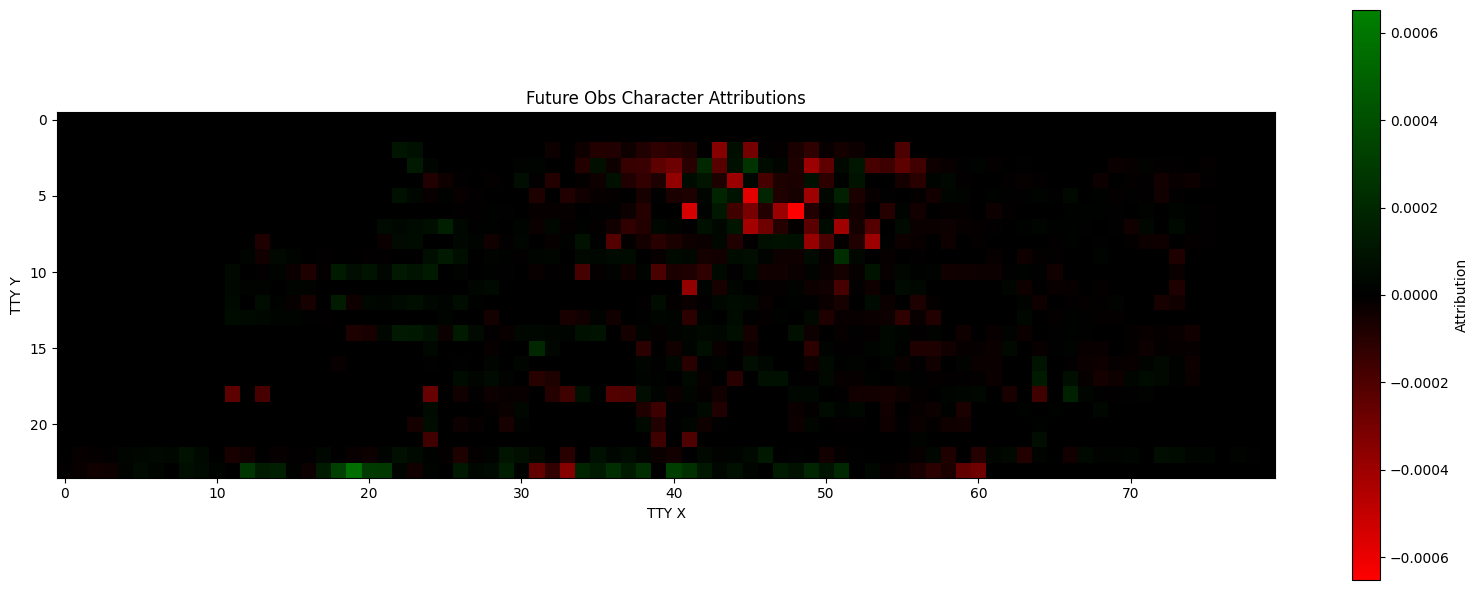

In [15]:
char_attributions = future_obs_attributions.mean(-1).squeeze().detach().cpu().numpy()

# Plot the ascii map (future obs tty_chars) before the attribution plot
plt.figure(figsize=(16, 6))
plt.imshow(render_tty_chars(raw_input_future_obs["tty_chars"]))
plt.title("Future Obs ASCII Map")
plt.xlabel("TTY X")
plt.ylabel("TTY Y")
plt.tight_layout()
plt.show()

from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap with black at the center
colors = [
    (1.0, 0.0, 0.0),  # Red for negative
    (0.0, 0.0, 0.0),  # Black at center (0)
    (0.0, 0.5, 0.0)   # Green for positive
]
cmap = LinearSegmentedColormap.from_list("custom_red_black_green", colors, N=256)
vmax = np.abs(char_attributions).max()
vmin = -vmax

# Plot using the custom colormap
plt.figure(figsize=(16, 6))
im = plt.imshow(char_attributions, cmap=cmap, interpolation='nearest', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Attribution')
plt.title("Future Obs Character Attributions")
plt.xlabel("TTY X")
plt.ylabel("TTY Y")
plt.tight_layout()
plt.show()


# Visualize similarity matrix used for training

In [21]:
from odyssey.data.cpc_dataset import CPCDataset

Changed code


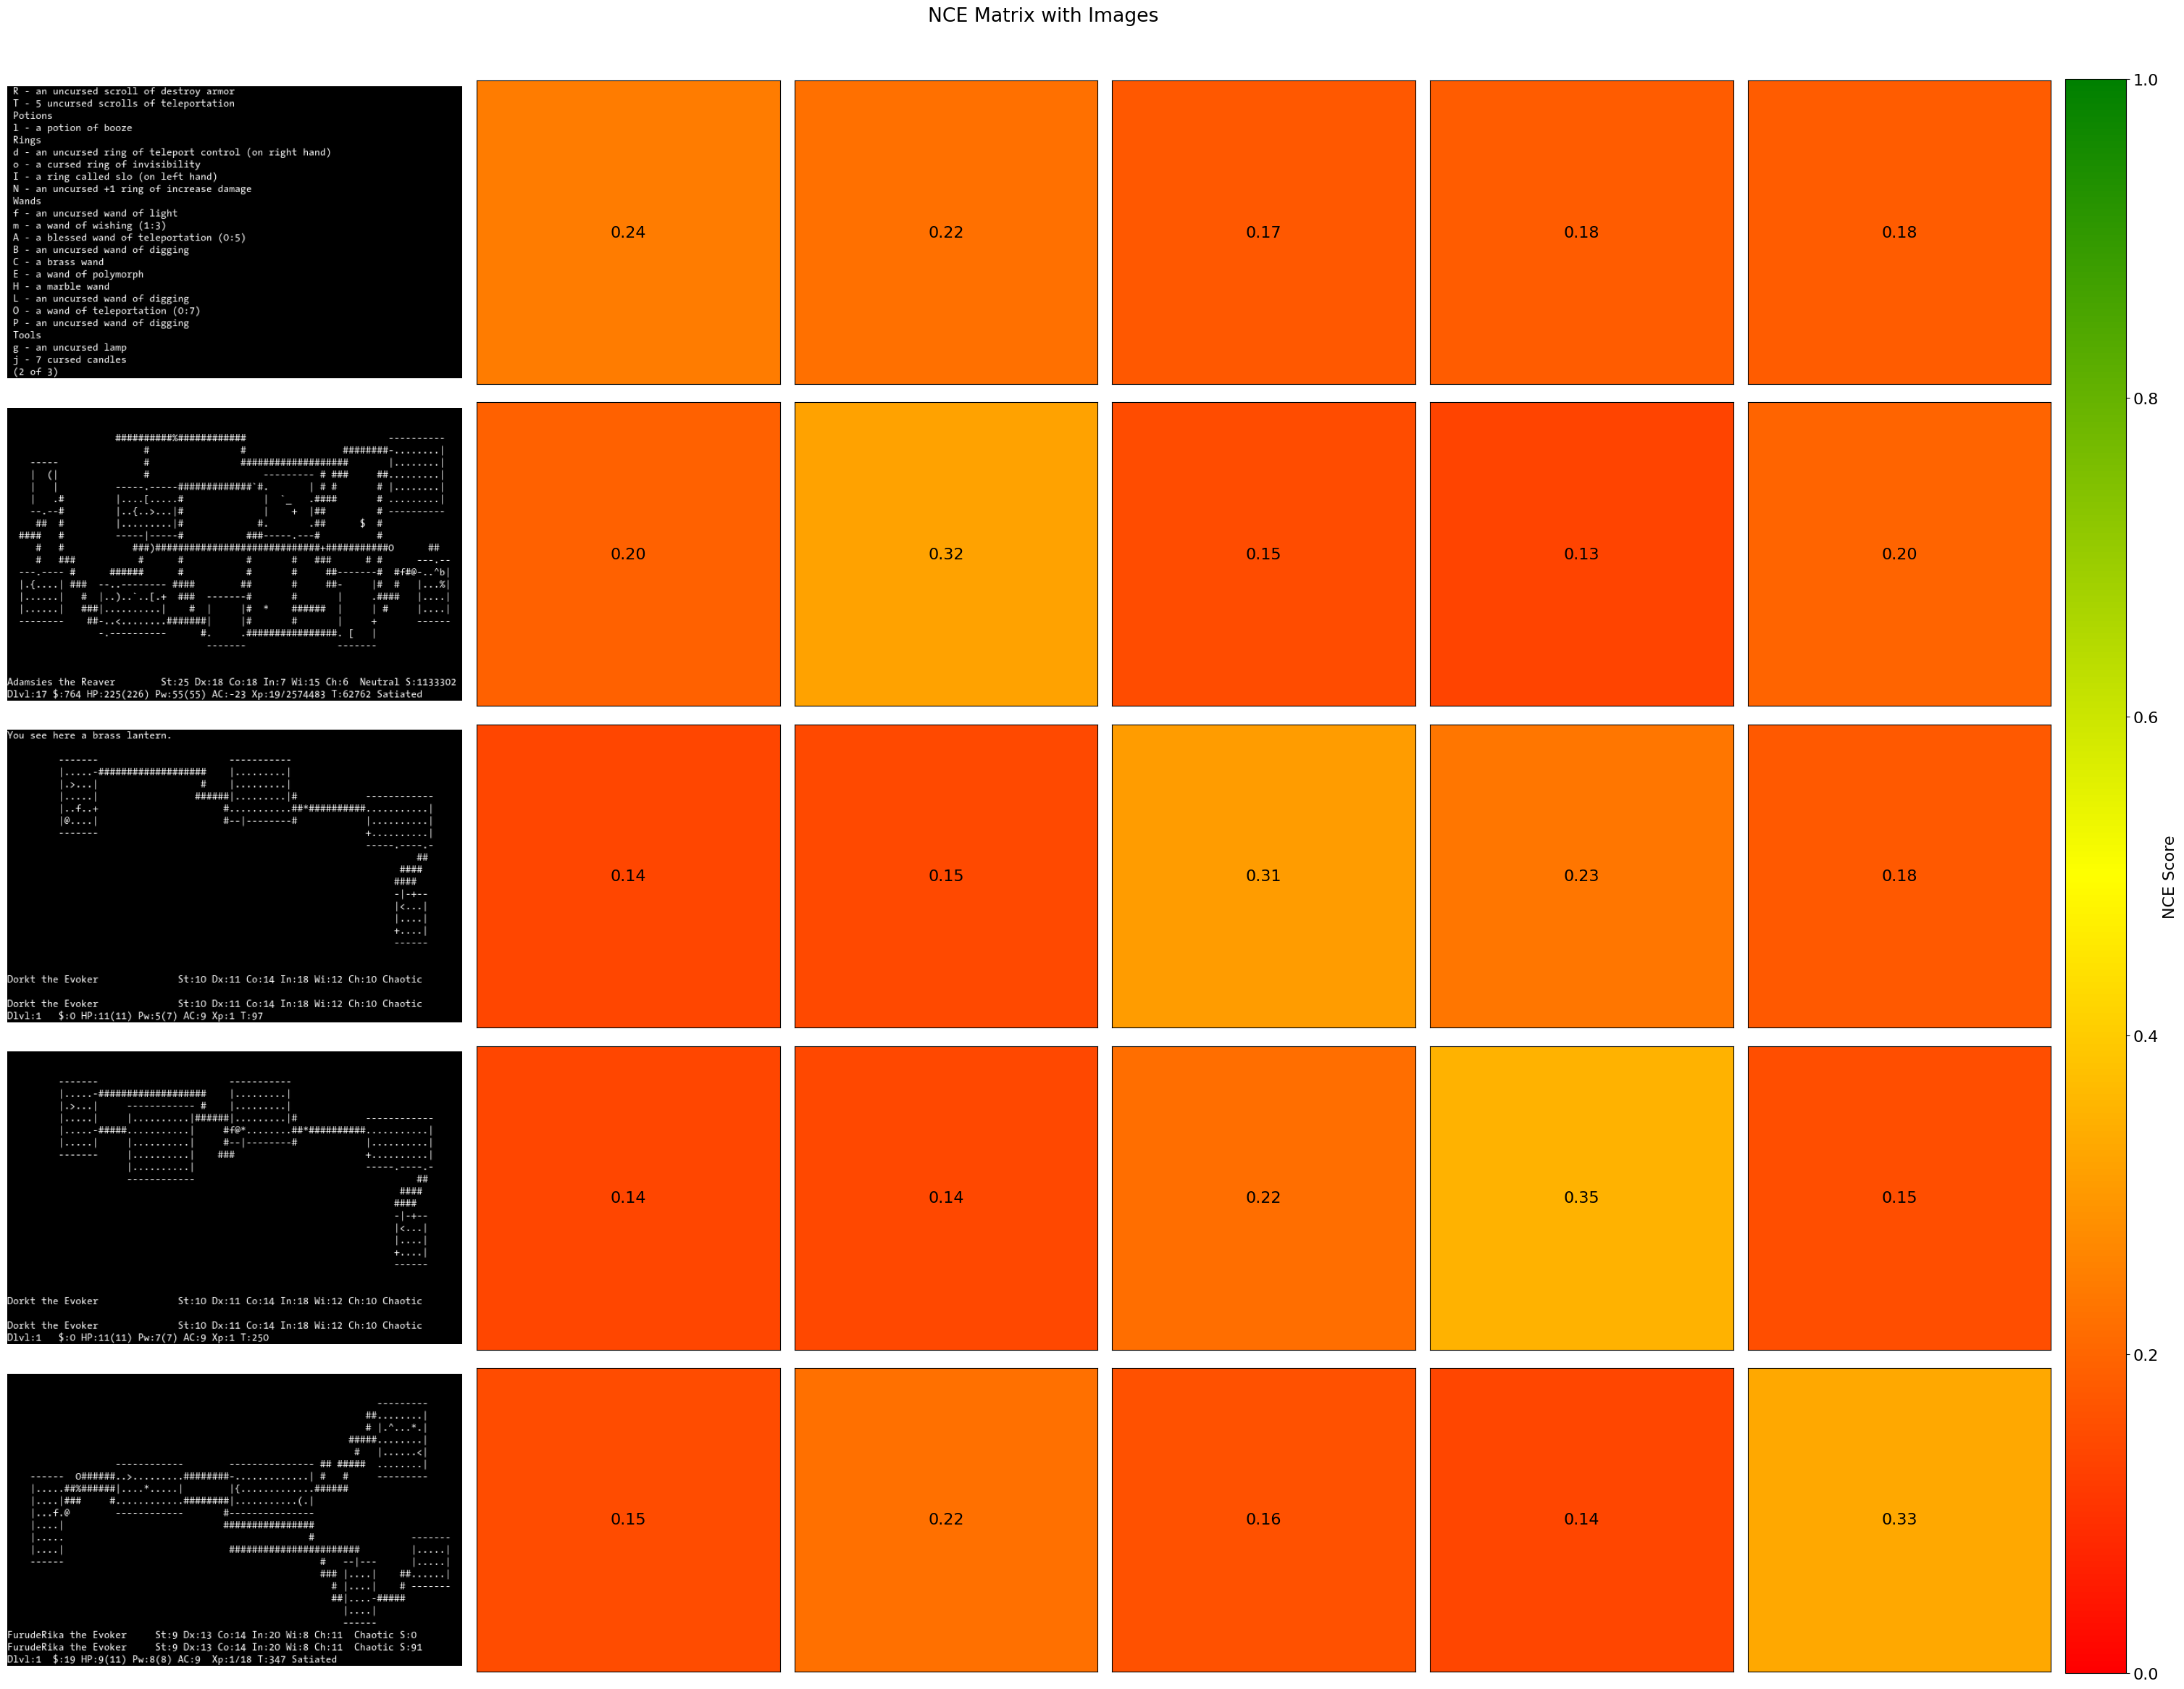

Changed code


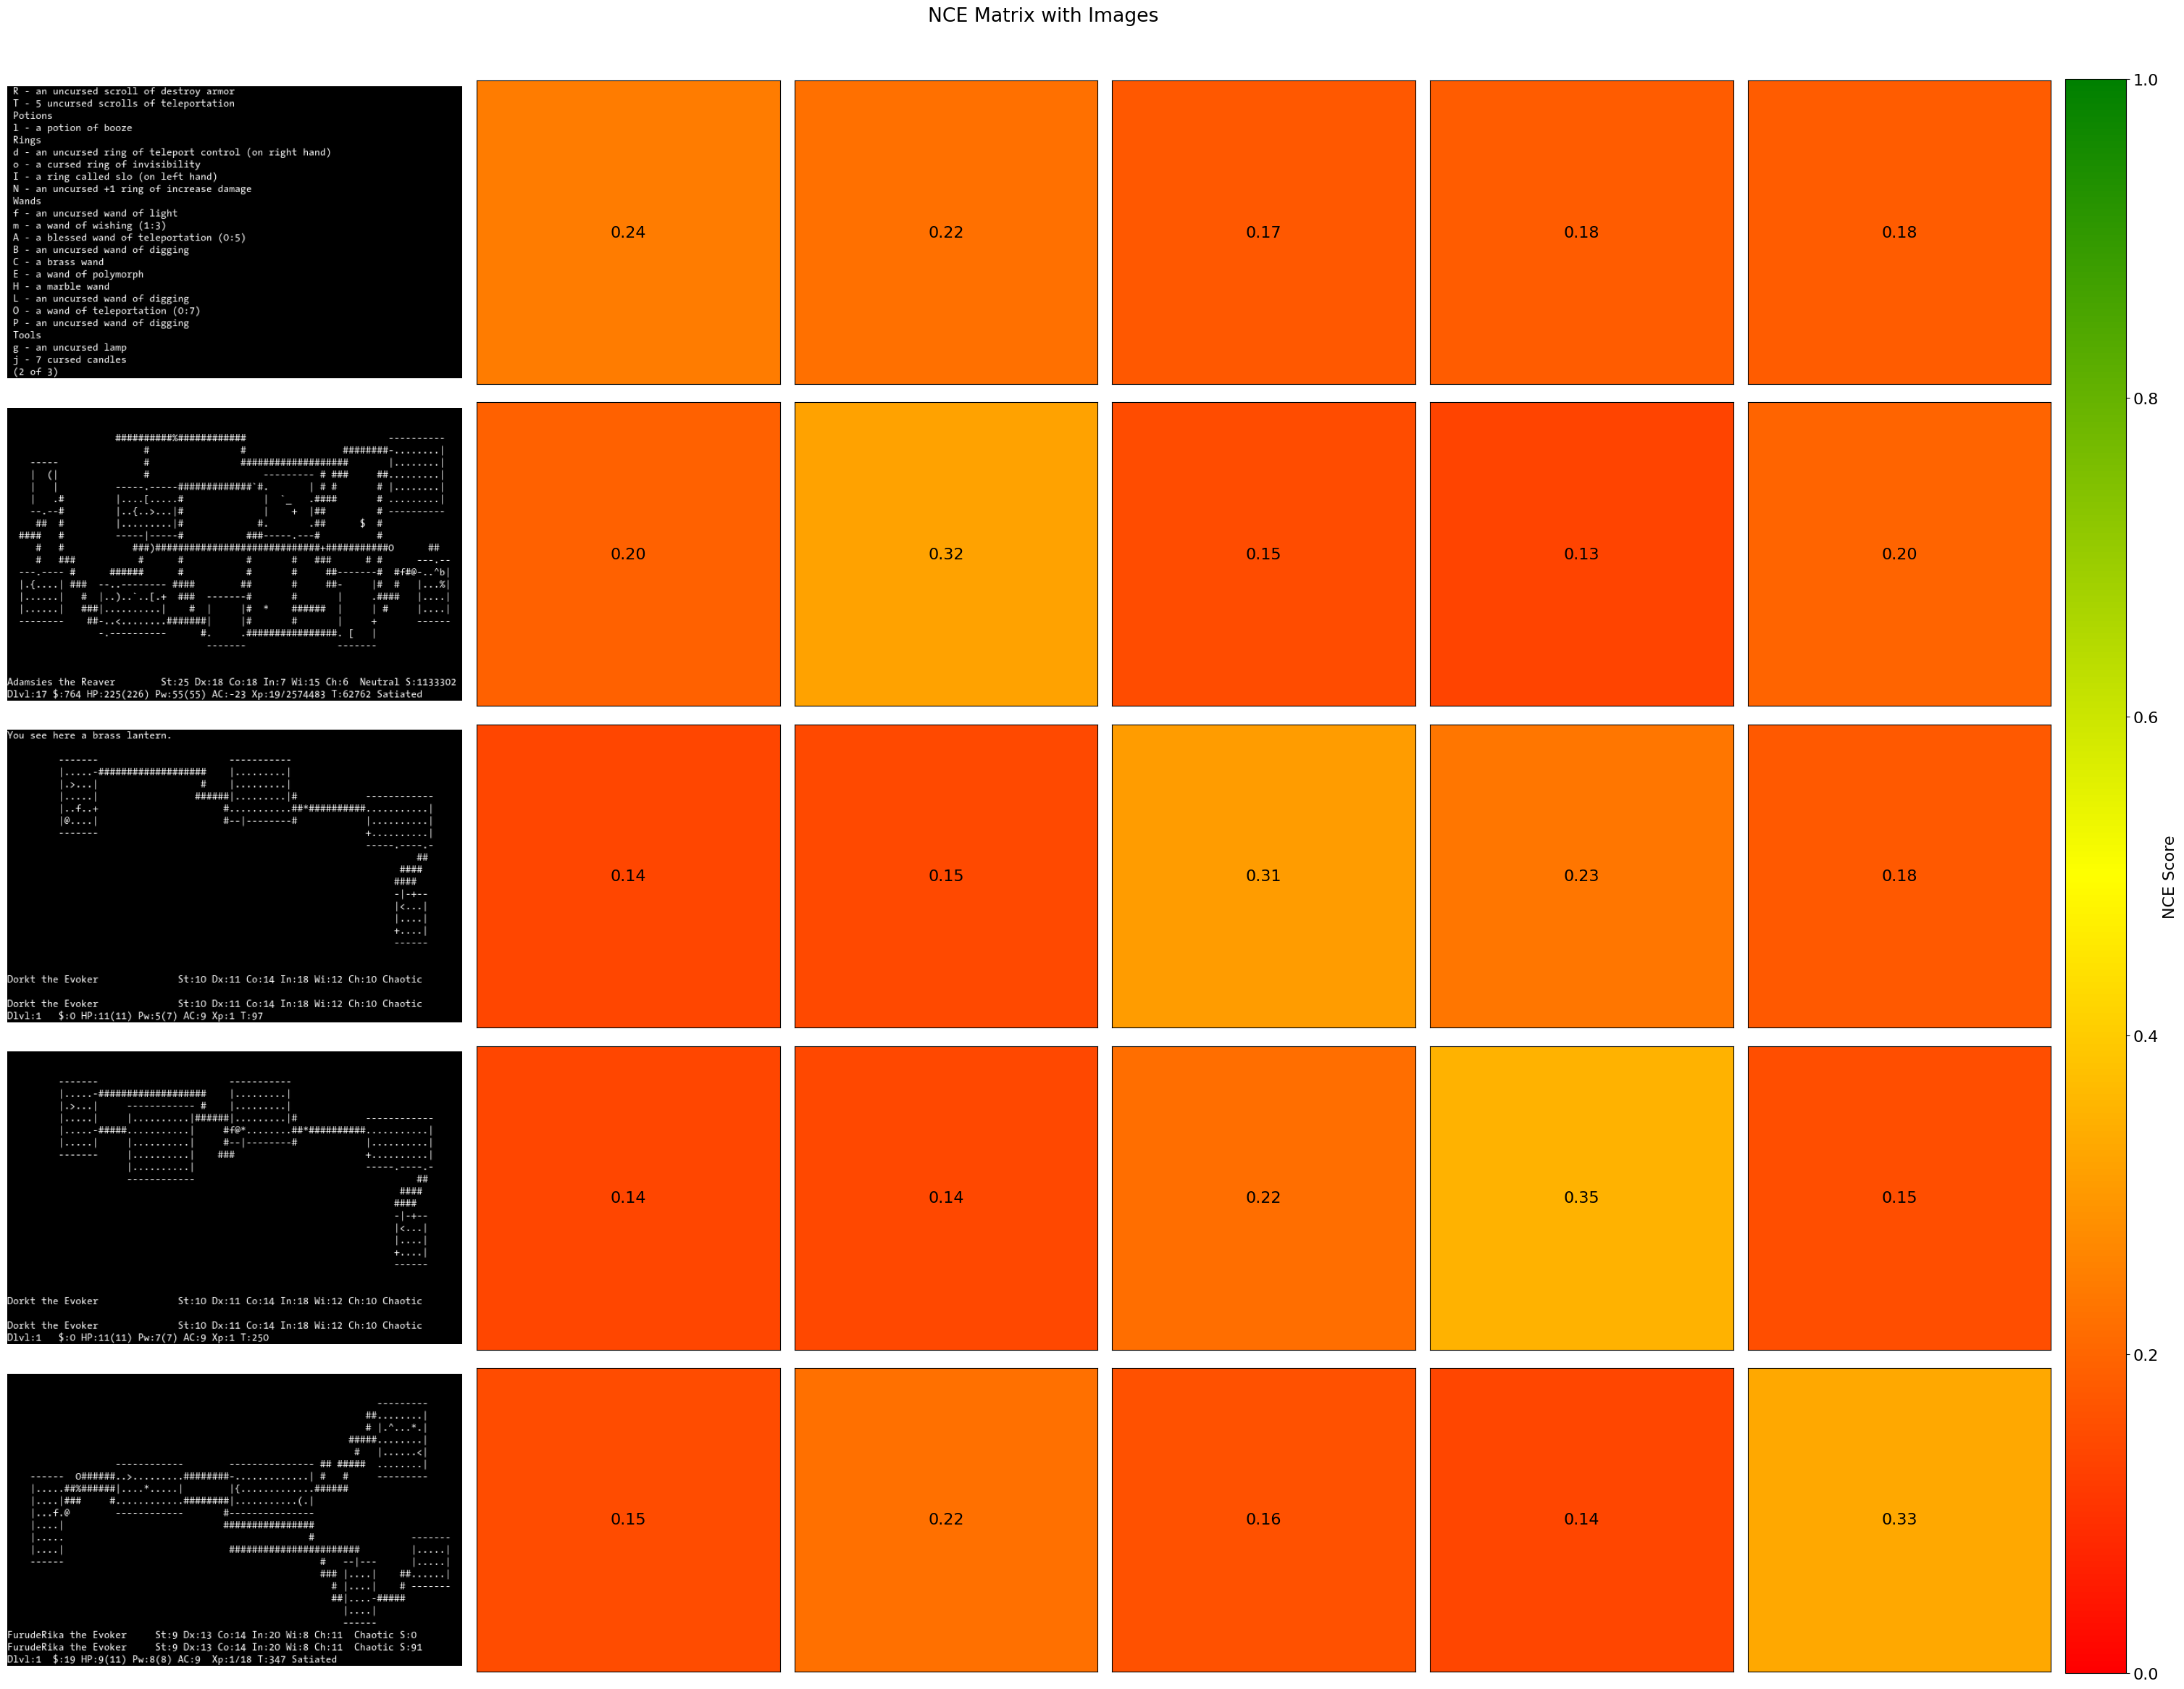

In [65]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def plot_nce_matrix_with_images(images, nce_matrix, cell_pad=0.05, image_col_width=1.5):
    grid_size = len(images)
    fig_width = 5 * (grid_size + image_col_width)
    fig_height = 5 * grid_size

    # Set global font size
    plt.rcParams.update({'font.size': 16})

    fig = plt.figure(figsize=(fig_width, fig_height))

    width_ratios = [image_col_width] + [1] * grid_size
    spec = gridspec.GridSpec(grid_size, grid_size + 2,  # +2 for colorbar
                              width_ratios=width_ratios + [0.2],
                              wspace=cell_pad, hspace=cell_pad)

    # Custom red-yellow-green colormap
    cmap = LinearSegmentedColormap.from_list("red_green", ["red", "yellow", "green"])
    vmin, vmax = -1, 1

    im_ax = None
    for i in range(grid_size):
        for j in range(grid_size):
            ax = fig.add_subplot(spec[i, j + 1])
            im_ax = ax.imshow([[nce_matrix[i, j]]], cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])

            # Centered text using axes coordinates
            val = nce_matrix[i, j]
            ax.text(0.5, 0.5, f"{val:.2f}", color="black",
                    ha="center", va="center", transform=ax.transAxes)

    # Image column
    for i, img in enumerate(images):
        ax_img = fig.add_subplot(spec[i, 0])
        ax_img.imshow(img)
        ax_img.axis('off')

    # Colorbar
    cbar_ax = fig.add_subplot(spec[:, -1])
    fig.colorbar(im_ax, cax=cbar_ax, label='NCE Score')

    # Layout and title
    plt.subplots_adjust(left=0.06, right=0.96, top=0.94, bottom=0.06)
    plt.suptitle("NCE Matrix with Images", y=0.98)
    plt.show()

def encode_obs(obs):
    obs = dict_to_tensor(obs)
    return tty_embedding.encode(**obs)

def predict_future_obs(context, indices):
    context_encoding = context_embedding(context)
    obs_predictions = future_obs_predictor.forward(
        context_encoding,
        indices,
    )
    return obs_predictions

def compute_similarities(context, future_obs, indices):
    obs_predictions = predict_future_obs(context, indices)
    return F.cosine_similarity(
        future_obs,
        obs_predictions,
    )

import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def plot_nce_matrix_with_images(images, nce_matrix, cell_pad=0.05, image_col_width=1.5):
    grid_size = len(images)
    fig_width = 5 * (grid_size + image_col_width)
    fig_height = 5 * grid_size

    # Set global font size
    plt.rcParams.update({'font.size': 16})

    fig = plt.figure(figsize=(fig_width, fig_height))

    width_ratios = [image_col_width] + [1] * grid_size
    spec = gridspec.GridSpec(grid_size, grid_size + 2,  # +2 for colorbar
                              width_ratios=width_ratios + [0.2],
                              wspace=cell_pad, hspace=cell_pad)

    # Custom red-yellow-green colormap
    cmap = LinearSegmentedColormap.from_list("red_green", ["red", "yellow", "green"])
    vmin, vmax = 0, 1

    im_ax = None
    for i in range(grid_size):
        for j in range(grid_size):
            ax = fig.add_subplot(spec[i, j + 1])
            im_ax = ax.imshow([[nce_matrix[i, j]]], cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])

            # Centered text using axes coordinates
            val = nce_matrix[i, j]
            ax.text(0.5, 0.5, f"{val:.2f}", color="black",
                    ha="center", va="center", transform=ax.transAxes)

    # Image column
    for i, img in enumerate(images):
        ax_img = fig.add_subplot(spec[i, 0])
        ax_img.imshow(img)
        ax_img.axis('off')

    # Colorbar
    cbar_ax = fig.add_subplot(spec[:, -1])
    fig.colorbar(im_ax, cax=cbar_ax, label='NCE Score')

    # Layout and title
    plt.subplots_adjust(left=0.06, right=0.96, top=0.94, bottom=0.06)
    plt.suptitle("NCE Matrix with Images", y=0.98)
    plt.show()

def encode_obs(obs):
    obs = dict_to_tensor(obs)
    return tty_embedding.encode(**obs)

def predict_future_obs(context, indices):
    context_encoding = context_embedding(context)
    obs_predictions = future_obs_predictor.forward(
        context_encoding,
        indices,
    )
    return obs_predictions

def compute_similarities(context, future_obs, indices):
    obs_predictions = predict_future_obs(context, indices)
    return F.cosine_similarity(
        future_obs,
        obs_predictions,
    )

import torch.nn.functional as F

def compute_similarity_matrix(queries: torch.Tensor, positive_keys: torch.Tensor):
    queries = F.normalize(queries, dim=-1)
    positive_keys = F.normalize(positive_keys, dim=-1)

    logits = queries @ positive_keys.T
    probs = F.softmax(logits, dim=1)  # row-wise softmax
    return probs

batch_size = 5
dataset = CPCDataset(
    h5py_file_path="./data/nld_nao_train.h5",
    batch_size=batch_size,
    context_length=context_length,
    future_length=future_length,
    samples_per_trajectory=2,
    seed=33
)
batch = next(iter(dataset))
with torch.no_grad():
    obs_encoding = encode_obs(batch["positive_samples"])
    context_encoding = encode_obs(batch["context"])
    obs_encoding_preds = predict_future_obs(context_encoding, batch["positive_indices"])
    nce_matrix = compute_similarity_matrix(obs_encoding, obs_encoding_preds)

plot_nce_matrix_with_images(
    images=[render_tty_chars(batch["positive_samples"]["tty_chars"][i]) for i in range(batch_size)],
    nce_matrix=nce_matrix.cpu().numpy()
)

batch_size = 5
dataset = CPCDataset(
    h5py_file_path="./data/nld_nao_train.h5",
    batch_size=batch_size,
    context_length=context_length,
    future_length=future_length,
    samples_per_trajectory=2,
    seed=33
)
batch = next(iter(dataset))
with torch.no_grad():
    obs_encoding = encode_obs(batch["positive_samples"])
    context_encoding = encode_obs(batch["context"])
    obs_encoding_preds = predict_future_obs(context_encoding, batch["positive_indices"])
    nce_matrix = compute_similarity_matrix(obs_encoding, obs_encoding_preds)

plot_nce_matrix_with_images(
    images=[render_tty_chars(batch["positive_samples"]["tty_chars"][i]) for i in range(batch_size)],
    nce_matrix=nce_matrix.cpu().numpy()
)

# Test if we can use the CPC Model for playing the game

In [16]:
import hydra
from odyssey.lightning.models.cpc import CPCModel
from odyssey.nn.nethack.tty_encoder import ResnetTTYEncoder
from odyssey.nn.contrastive.context_transformer import ContextTransformer
import torch
import torch.nn as nn
import os
from omegaconf import OmegaConf
import h5py

logdir = "/workspace/logs/train_cpc/runs/2025-06-08_16-31-09"
chkpt_name = "last-v3.ckpt"
data_path = "/workspace/data/nld_nao_test.h5"
device = "cuda" if torch.cuda.is_available() else "cpu"

config_path = os.path.join(logdir, ".hydra", "config.yaml")
config = OmegaConf.load(config_path)
chkpt = torch.load(os.path.join(logdir, "checkpoints", chkpt_name))
data = h5py.File("/workspace/data/nld_nao_train.h5", "r")

lightning_model: CPCModel = hydra.utils.instantiate(config.model)
lightning_model.load_state_dict(chkpt["state_dict"])
lightning_model = lightning_model.to(device)
lightning_model.freeze()

tty_embedding: ResnetTTYEncoder = lightning_model.tty_embedding
# replace_all_batch_norm_modules_(tty_embedding.resnet)
context_embedding: ContextTransformer = lightning_model.context_embedding
future_obs_predictor = lightning_model.future_obs_predictor
future_length = config.future_length
context_length = config.context_length

In [17]:
class CircularBuffer(nn.Module):
    def __init__(self, size, embedding_dim):
        super().__init__()
        self.size = size
        self.embedding_dim = embedding_dim
        self.buffer = nn.Parameter(torch.zeros(size, embedding_dim), requires_grad=False)
        self.next_index = 0
        self.is_full = False

    def append(self, embedding):
        self.buffer[self.next_index] = embedding
        self.next_index = (self.next_index + 1) % self.size
        if self.next_index == 0:
            self.is_full = True

    def reset(self):
        self.buffer[:] = 0
        self.next_index = 0
        self.is_full = False

    def get_data(self):
        if self.is_full:
            return torch.roll(self.buffer, -self.next_index, dims=0)
        else:
            return self.buffer[:self.next_index]

class ContrastiveRewardModule(nn.Module):
    def __init__(self, context_length=100):
        super().__init__()
        self.context_length = context_length
        self.buffer = CircularBuffer(context_length, tty_embedding.embedding_dim).to(device)

    def reset(self, initial_obs):
        self.buffer.reset()
        self.buffer.append(self._compute_obs_embedding(initial_obs))
    
    def add_obs(self, obs):
        self.buffer.append(self._compute_obs_embedding(obs))

    def get_context(self):
        return self.buffer.get_data()
    
    def get_reward(self, context, obs) -> float:
        c_embedding = context_embedding.forward(observations=context.unsqueeze(0))
        predicted_obs = future_obs_predictor.forward(
            input=c_embedding,
            indices=torch.LongTensor([0]).to(device)
        ).squeeze(0)
        obs_embedding = self._compute_obs_embedding(obs)

        similarity_reward = torch.nn.functional.cosine_similarity(
            predicted_obs,
            obs_embedding,
            dim=0
        ).item()
        return similarity_reward
    
    def _compute_obs_embedding(self, obs):
        obs_embedding = tty_embedding.forward(
            tty_chars=torch.tensor(obs["tty_chars"]).unsqueeze(0).to(device),
            tty_colors=torch.tensor(obs["tty_colors"]).unsqueeze(0).to(device),
            tty_cursor=torch.tensor(obs["tty_cursor"]).unsqueeze(0).to(device)
        ).squeeze(0)

        return obs_embedding

In [55]:
import gymnasium as gym
import nle
import numpy as np
import matplotlib.pyplot as plt
import cv2
from typing import List
from copy import deepcopy
from odyssey.nethack.render import render_tty_chars
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

def recreate_env(seed: int, actions: List[int], expected_last_obs, num_tries=5):
    for _ in range(num_tries):
        env = gym.make("NetHackScore-v0")
        env.unwrapped.seed(seed, seed)
        obs, _ = env.reset()

        for act in actions:
            obs, *_ = env.step(act)

        if expected_last_obs is None or (obs["tty_chars"] == expected_last_obs["tty_chars"]).all():
            return env, obs
        env.close()
    raise Exception("Failed to recreate env")

def evaluate_actions(env_fn, actions, reward_fn):
    rewards = []
    for action in actions:
        env, _ = env_fn()
        step_data = env.step(action)
        reward = reward_fn(*step_data)
        rewards.append(reward)
        env.close()

    return rewards

# --- MAIN ---
seed = 42
max_steps = 20
env = gym.make("NetHackScore-v0")
available_actions = list(range(env.action_space.n))

executed_actions = []
last_obs = None
trajectory = []
reward_module = ContrastiveRewardModule(context_length=context_length)
reward_fn = lambda obs, *_: reward_module.get_reward(reward_module.get_context(), obs)

_, initial_obs = recreate_env(seed, [], None)
reward_module.reset(initial_obs)

frames = [render_tty_chars(initial_obs["tty_chars"])]
scores = []
for step in range(max_steps):
    env_fn = lambda: recreate_env(seed, executed_actions, last_obs)
    scores = evaluate_actions(env_fn, available_actions, reward_fn)

    #probabilities = np.array(scores) / np.sum(scores)
    #best_action = np.random.choice(available_actions, p=probabilities)
    #best_action = np.random.choice(available_actions)
    best_action = available_actions[np.argmax(scores)]

    env, _ = recreate_env(seed, executed_actions, last_obs)
    last_obs, *_ = env.step(best_action)
    reward_module.add_obs(last_obs)
    executed_actions.append(best_action)

    frames.append(render_tty_chars(last_obs["tty_chars"]))
    scores.append(scores)

In [56]:
import os
import cv2
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

import matplotlib.pyplot as plt

# Create a directory to store the frames
os.makedirs("frames", exist_ok=True)

# Generate frames
for i, frame in enumerate(frames):
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [2, 1]})
    ax_img.imshow(frame)
    ax_img.axis("off")
    ax_img.set_title(f"Frame {i + 1}")

    if i < len(scores):
        top_n = 10
        top_scores = sorted(zip(scores, available_actions), reverse=True)[:top_n]
        top_scores_values, top_actions = zip(*top_scores)
        action_names = [x.name for x in env.unwrapped.actions]

        ax_bar.barh(range(top_n), top_scores_values, color='tab:blue')
        ax_bar.set_yticks(range(top_n))
        ax_bar.set_yticklabels([action_names[action] for action in top_actions])
        ax_bar.set_xlabel("Score")
        ax_bar.set_title("Top Action Scores")
        ax_bar.set_xlim(-1, 1)

    # Save the frame
    canvas = FigureCanvas(fig)
    canvas.draw()
    argb = np.frombuffer(canvas.tostring_argb(), dtype=np.uint8)
    width, height = canvas.get_width_height()
    argb = argb.reshape((height, width, 4))

    # Convert ARGB to RGB
    rgb = argb[:, :, [1, 2, 3]]  # Drop alpha, reorder channels

    # Save image using OpenCV
    cv2.imwrite(f"frames/frame_{i:03d}.png", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    plt.close(fig)

# Combine frames into a video using OpenCV
frame_height, frame_width, _ = rgb.shape
video_writer = cv2.VideoWriter("output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 1, (frame_width, frame_height))

for i in range(len(frames)):
    frame = cv2.imread(f"frames/frame_{i:03d}.png")
    video_writer.write(frame)

video_writer.release()